# Map

In [1]:
from ipyopenlayers import (
    Map, RasterTileLayer
)
import configparser
import requests
import unicodedata

m = Map(center=[0.0, 0.0], zoom=2)
layer= RasterTileLayer()
m.add_layer(layer)
m

Map(center=[0.0, 0.0], zoom=2.0)

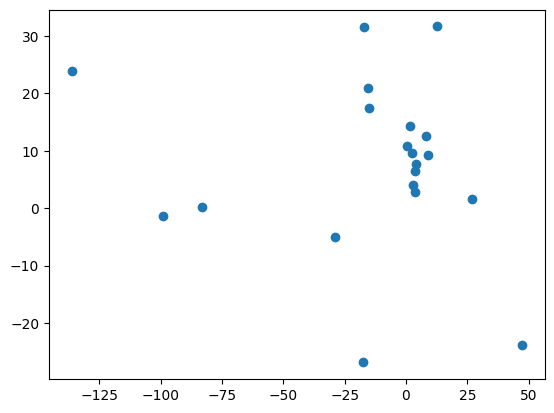

generated on 2026-03-12T02:33:25.084Z


In [17]:
import shapely
exported_shapely = shapely.from_geojson("{\"type\":\"FeatureCollection\",\"features\":[{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-14.94053777189022,17.4177568971661]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-15.644846715892829,20.892992758383613]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-17.292778211237366,31.529766305496565]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[12.743445307309061,31.68386905405464]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[3.8432304333636766,6.499362264757039]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[9.090507484969516,9.187827166299371]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[2.395712127234312,9.544881519290811]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[0.5862943658124175,10.791550372746471]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[8.185811856765367,12.563434388759404]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[1.4909899940165667,14.323184903547343]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[4.20510338364261,7.756129925112006]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-17.650587621293536,-26.910111162697625]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[47.484070189509055,-23.920943342602456]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[27.03773165098372,1.5884606053354986]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[2.7575850775132458,3.9769715390140874]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[3.4813574830847096,2.8932930586422287]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-136.39083581397148,23.859418356860132]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-99.25900257794422,-1.3062858063597673]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-83.03793443383464,0.11610521407368424]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-29.05392739794572,-5.09941206488358]},\"properties\":null}]}")
plt.scatter(shapely.get_coordinates(exported_shapely)[:, 0],shapely.get_coordinates(exported_shapely)[:, 1])
plt.show()
print("generated on 2026-03-12T02:33:25.084Z")

In [16]:
import shapely
import matplotlib.pyplot as plt
exported_shapely = shapely.from_geojson("{\"type\":\"FeatureCollection\",\"features\":[{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-136.39083581397148,23.859418356860132]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-15.644846715892829,20.892992758383613]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-17.650587621293536,-26.910111162697625]},\"properties\":null},{\"type\":\"Feature\",\"geometry\":{\"type\":\"Point\",\"coordinates\":[-83.03793443383464,0.11610521407368424]},\"properties\":null}]}")
plt.scatter(shapely.get_coordinates(exported_shapely)[:, 0],shapely.get_coordinates(exported_shapely)[:, 1])
plt.show()
print("generated on 2026-03-12T02:21:57.511Z")

generated on 2026-03-12T02:21:57.511Z


In [8]:
config = configparser.ConfigParser()
config.read('../.env.ini')
api_key = config['DEFAULT']['api_key']

In [9]:
def get_country_from_coordinates_geoapify(**kwargs):
    lon = kwargs.get('lon')
    lat = kwargs.get('lat')
    url = f"https://api.geoapify.com/v1/geocode/reverse?lat={lat}&lon={lon}&apiKey={api_key}"
    
    response = requests.get(url)
    data = response.json()
    
    features = data.get('features', [])
    if features:
        first_feature = features[0]
        properties = first_feature.get('properties', {})
        country = properties.get('country', None)
        normalized_name = country.split(' ')[0]
        normalized_name = unicodedata.normalize('NFKD', normalized_name)
        normalized_name = normalized_name.encode('ASCII', 'ignore').decode('utf-8')
        print(f"Country: {normalized_name}")

m.on_click(get_country_from_coordinates_geoapify)